# Neutron Transmission Through Water Using OpenMC

## Objective
Investigate how water thickness affects rear-face transmission
of a normally incident 1 MeV neutron pencil beam.

## Approach
- Model a water slab with a 40 × 40 cm face.
- Compare thicknesses of 1, 2, 5, 10, and 20 cm.
- Verify the setup using a vacuum transmission case.
- Study statistical uncertainty using 30,000 to 3,000,000 histories.

## Tools
Python, OpenMC 0.15.3, NumPy, and Matplotlib.

In [1]:
import os
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import openmc

# Locate the working nuclear-data index.
data_index = (
    Path("nuclear_data")
    / "water_endfb71"
    / "cross_sections.xml"
).resolve()

if not data_index.is_file():
    raise FileNotFoundError(
        f"Nuclear-data index not found:\n{data_index}"
    )

# Tell OpenMC where to find the nuclear data.
openmc.config["cross_sections"] = str(data_index)
os.environ["OPENMC_CROSS_SECTIONS"] = str(data_index)

print("OpenMC version:", openmc.__version__)
print("Nuclear-data index:", data_index)
print("Setup complete.")

OpenMC version: 0.15.3
Nuclear-data index: /root/OpenMC/openmc/nuclear_data/water_endfb71/cross_sections.xml
Setup complete.


## Model Definition

We model a 5 cm thick water slab with a 40 × 40 cm face.

- Material: water at 0.997 g/cm³ and 293.6 K.
- Source: a 1 MeV neutron pencil beam directed along +x.
- Boundaries: neutrons leaving the model do not return.
- Measurement: the fraction of source neutrons exiting the rear face.

Transmission includes neutrons that scattered before exiting.

In [2]:
import openmc

# Units: distances in centimeters, neutron energies in electron volts.
thickness = 5.0

# 1. Material: water at approximately room temperature.
water = openmc.Material(name="Water")
water.add_nuclide("H1", 2.0)
water.add_nuclide("O16", 1.0)
water.set_density("g/cm3", 0.997)
water.temperature = 293.6

# Account for hydrogen atoms being bound in water molecules.
water.add_s_alpha_beta("c_H_in_H2O")

# 2. Geometry: a 40 × 40 cm slab with a small vacuum gap for the source.
left = openmc.XPlane(x0=-1.0, boundary_type="vacuum")
front = openmc.XPlane(x0=0.0)
back = openmc.XPlane(x0=thickness, boundary_type="vacuum")

y_min = openmc.YPlane(y0=-20.0, boundary_type="vacuum")
y_max = openmc.YPlane(y0=20.0, boundary_type="vacuum")
z_min = openmc.ZPlane(z0=-20.0, boundary_type="vacuum")
z_max = openmc.ZPlane(z0=20.0, boundary_type="vacuum")

# + means the positive side of a surface; - means the negative side.
# & means that all these spatial conditions must hold.
sides = +y_min & -y_max & +z_min & -z_max

source_gap = openmc.Cell(
    name="Vacuum source gap",
    region=+left & -front & sides,
)

slab = openmc.Cell(
    name="Water slab",
    fill=water,
    region=+front & -back & sides,
)

geometry = openmc.Geometry([source_gap, slab])

# 3. Source: 1 MeV neutrons traveling in the positive x direction.
source = openmc.IndependentSource(
    space=openmc.stats.Point((-0.5, 0.0, 0.0)),
    angle=openmc.stats.Monodirectional((1.0, 0.0, 0.0)),
    energy=openmc.stats.Discrete([1.0e6], [1.0]),
)

settings = openmc.Settings()
settings.run_mode = "fixed source"
settings.source = source
settings.batches = 30
settings.particles = 10_000
settings.seed = 12345

# 4. Measurement: count neutrons leaving the rear face.
transmission = openmc.Tally(name="transmission")
transmission.filters = [openmc.SurfaceFilter(back)]
transmission.scores = ["current"]

model = openmc.Model(
    geometry=geometry,
    materials=openmc.Materials([water]),
    settings=settings,
    tallies=openmc.Tallies([transmission]),
)

model.materials.cross_sections = str(data_index)

print("Model created.")
print(f"Water slab: {thickness} cm thick, 40 × 40 cm face")
print(f"Neutron histories: {settings.batches * settings.particles:,}")

Model created.
Water slab: 5.0 cm thick, 40 × 40 cm face
Neutron histories: 300,000


## Baseline Simulation: 5 cm Water Slab

Simulate 300,000 neutron histories and measure the fraction
exiting the rear face. Report uncertainty as one standard error.

In [3]:
# Save this run in a separate folder.
run_directory = (
    Path("runs")
    / datetime.now().strftime("water_5cm_%Y%m%d_%H%M%S_%f")
)
run_directory.mkdir(parents=True, exist_ok=True)

statepoint_path = model.run(cwd=run_directory, threads=2)

# Read the transmission tally.
with openmc.StatePoint(statepoint_path) as results:
    tally = results.get_tally(name="transmission")
    transmission_fraction = float(tally.mean.ravel()[0])
    standard_error = float(tally.std_dev.ravel()[0])

print(f"\nTransmitted neutrons: {100 * transmission_fraction:.2f}%")
print(f"Standard error: {100 * standard_error:.2f} percentage points")
print("Results saved to:", statepoint_path)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

## Vacuum Verification

Remove the water while keeping the geometry and source unchanged.
Every neutron in the directed beam should exit the rear face,
giving 100% transmission.

This checks the source direction, geometry, and transmission tally.
It does not validate the water interaction physics.

In [4]:
vacuum_directory = (
    Path("runs")
    / datetime.now().strftime("vacuum_check_%Y%m%d_%H%M%S_%f")
)
vacuum_directory.mkdir(parents=True, exist_ok=True)

original_fill = slab.fill

try:
    # Temporarily remove the water.
    slab.fill = None
    vacuum_statepoint = model.run(
        cwd=vacuum_directory,
        threads=2,
        output=False,
    )
finally:
    # Restore the water even if the run fails.
    slab.fill = original_fill

with openmc.StatePoint(vacuum_statepoint) as results:
    tally = results.get_tally(name="transmission")
    vacuum_transmission = float(tally.mean.ravel()[0])
    vacuum_error = float(tally.std_dev.ravel()[0])

print(f"Vacuum transmission: {100 * vacuum_transmission:.6f}%")
print(f"Standard error: {100 * vacuum_error:.6f} percentage points")

assert abs(vacuum_transmission - 1.0) < 1e-10, (
    "Vacuum verification failed: investigate before continuing."
)

print("Verification: PASS")

Vacuum transmission: 100.000000%
Standard error: 0.000000 percentage points
Verification: PASS


## Effect of Water Thickness

Compare rear-face transmission through 1, 2, 5, 10, and 20 cm
of water, using 300,000 neutron histories per case.

Keep the source energy, slab face dimensions, and material
properties unchanged. Use a different random seed for each case.

Error bars represent one standard error. Lines connect the
calculated points as visual guides.

In [5]:
study_directory = (
    Path("runs")
    / datetime.now().strftime("thickness_study_%Y%m%d_%H%M%S_%f")
)
study_directory.mkdir(parents=True, exist_ok=True)

thicknesses = [1, 2, 5, 10, 20]
study_results = []

original_position = back.x0
original_seed = model.settings.seed
original_fill = slab.fill

try:
    slab.fill = water

    for i, thickness_cm in enumerate(thicknesses):
        back.x0 = float(thickness_cm)
        model.settings.seed = 12345 + 1000 * i

        case_directory = study_directory / f"water_{thickness_cm}cm"
        case_directory.mkdir()

        print(f"Running {thickness_cm} cm slab...", flush=True)

        result_path = model.run(
            cwd=case_directory,
            threads=2,
            output=False,
        )

        with openmc.StatePoint(result_path) as results:
            tally = results.get_tally(name="transmission")
            mean = float(tally.mean.ravel()[0])
            error = float(tally.std_dev.ravel()[0])

        study_results.append({
            "thickness_cm": thickness_cm,
            "transmission": mean,
            "standard_error": error,
            "seed": model.settings.seed,
            "histories": (
                model.settings.batches * model.settings.particles
            ),
        })

        print(
            f"  Transmission: {100 * mean:.2f}% "
            f"+/- {100 * error:.2f} percentage points"
        )

finally:
    back.x0 = original_position
    model.settings.seed = original_seed
    slab.fill = original_fill

csv_path = study_directory / "transmission_results.csv"

with csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=study_results[0].keys())
    writer.writeheader()
    writer.writerows(study_results)

print("\nResults saved to:", csv_path)

Running 1 cm slab...
  Transmission: 86.68% +/- 0.06 percentage points
Running 2 cm slab...
  Transmission: 75.76% +/- 0.07 percentage points
Running 5 cm slab...
  Transmission: 51.04% +/- 0.08 percentage points
Running 10 cm slab...
  Transmission: 20.82% +/- 0.07 percentage points
Running 20 cm slab...
  Transmission: 1.50% +/- 0.02 percentage points

Results saved to: runs/thickness_study_20260908_214137_545817/transmission_results.csv


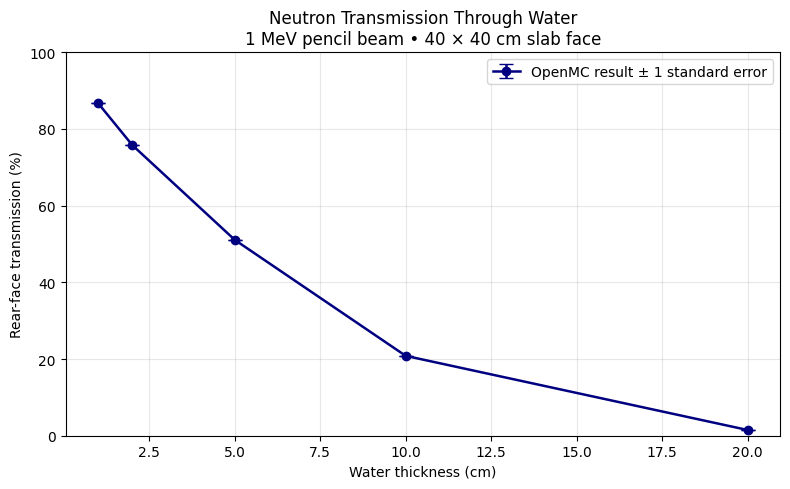

Figure saved to: runs/thickness_study_20260908_214137_545817/transmission_vs_thickness.png


In [6]:
x = [row["thickness_cm"] for row in study_results]
y = [100 * row["transmission"] for row in study_results]
errors = [100 * row["standard_error"] for row in study_results]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    x, y,
    yerr=errors,
    fmt="o-",
    capsize=5,
    linewidth=1.8,
    color="navy",
    label="OpenMC result ± 1 standard error",
)

ax.set(
    xlabel="Water thickness (cm)",
    ylabel="Rear-face transmission (%)",
    title="Neutron Transmission Through Water\n"
          "1 MeV pencil beam • 40 × 40 cm slab face",
    ylim=(0, 100),
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = study_directory / "transmission_vs_thickness.png"
fig.savefig(figure_path, dpi=300)
plt.show()

print("Figure saved to:", figure_path)

## Statistical Convergence

For the 5 cm water slab, compare 30,000, 300,000, and
3,000,000 neutron histories using independent random seeds.

Check whether transmission remains consistent while its
standard error decreases approximately as 1/sqrt(N).

This measures sampling convergence, not physical-model accuracy.

In [7]:
convergence_directory = (
    Path("runs")
    / datetime.now().strftime("convergence_%Y%m%d_%H%M%S_%f")
)
convergence_directory.mkdir(parents=True, exist_ok=True)

convergence_results = []

saved_settings = (
    back.x0,
    slab.fill,
    model.settings.particles,
    model.settings.batches,
    model.settings.seed,
)

try:
    back.x0 = 5.0
    slab.fill = water
    model.settings.batches = 30

    for i, particles_per_batch in enumerate([1000, 10000, 100000]):
        model.settings.particles = particles_per_batch
        model.settings.seed = 54321 + 1000 * i

        histories = model.settings.batches * particles_per_batch
        case_directory = convergence_directory / f"N_{histories}"
        case_directory.mkdir()

        print(f"Running {histories:,} histories...", flush=True)

        result_path = model.run(
            cwd=case_directory,
            threads=2,
            output=False,
        )

        with openmc.StatePoint(result_path) as results:
            tally = results.get_tally(name="transmission")
            mean = float(tally.mean.ravel()[0])
            error = float(tally.std_dev.ravel()[0])

        convergence_results.append({
            "histories": histories,
            "transmission": mean,
            "standard_error": error,
            "seed": model.settings.seed,
        })

        print(
            f"  Transmission: {100 * mean:.3f}% "
            f"+/- {100 * error:.3f} percentage points"
        )

finally:
    (
        back.x0,
        slab.fill,
        model.settings.particles,
        model.settings.batches,
        model.settings.seed,
    ) = saved_settings

csv_path = convergence_directory / "convergence_results.csv"

with csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(
        file, fieldnames=convergence_results[0].keys()
    )
    writer.writeheader()
    writer.writerows(convergence_results)

print("\nResults saved to:", csv_path)

Running 30,000 histories...
  Transmission: 50.960% +/- 0.273 percentage points
Running 300,000 histories...
  Transmission: 51.027% +/- 0.084 percentage points
Running 3,000,000 histories...
  Transmission: 51.020% +/- 0.029 percentage points

Results saved to: runs/convergence_20260908_214156_256036/convergence_results.csv


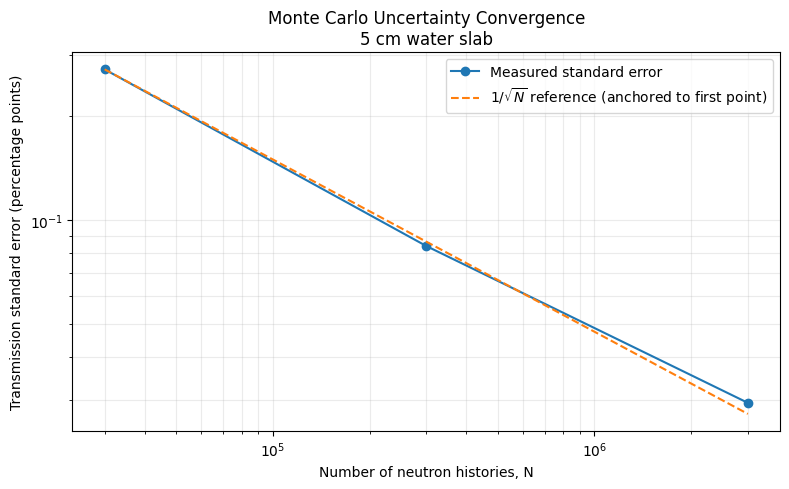

Figure saved to: runs/convergence_20260908_214156_256036/uncertainty_convergence.png


In [8]:
histories = np.array([
    row["histories"] for row in convergence_results
])
errors = np.array([
    100 * row["standard_error"] for row in convergence_results
])

reference = errors[0] * np.sqrt(histories[0] / histories)

fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(
    histories, errors, "o-",
    label="Measured standard error",
)
ax.loglog(
    histories, reference, "--",
    label=r"$1/\sqrt{N}$ reference (anchored to first point)",
)

ax.set(
    xlabel="Number of neutron histories, N",
    ylabel="Transmission standard error (percentage points)",
    title="Monte Carlo Uncertainty Convergence\n5 cm water slab",
)
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()

figure_path = convergence_directory / "uncertainty_convergence.png"
fig.savefig(figure_path, dpi=300)
plt.show()

print("Figure saved to:", figure_path)

## Conclusions

- Increasing water thickness reduced rear-face neutron transmission.
- Transmission decreased from approximately 87% at 1 cm to 2% at
  20 cm for the modeled 1 MeV pencil beam.
- The vacuum verification case reproduced 100% transmission.
- The 5 cm convergence study produced transmission near 51%.
- Statistical uncertainty decreased approximately as 1/sqrt(N).

## Limitations

- The source is an idealized monoenergetic pencil beam.
- The slab has finite dimensions, allowing neutrons to escape
  through its front and sides.
- Transmission includes scattered and uncollided neutrons.
- Absorption and leakage through other faces were not tallied
  separately.
- Reported errors represent Monte Carlo sampling uncertainty.
  Nuclear-data and modeling uncertainties were not quantified.
- No comparison with an experimental benchmark was performed.
- Transmission is not a radiation-dose measurement.

## Software and Nuclear Data

- OpenMC version: 0.15.3
- Nuclear data: official OpenMC ENDF/B-VII.1 processed library
- Datasets: H1, O16, and c_H_in_H2O
- Water temperature: 293.6 K
- Water density: 0.997 g/cm³

## References

- [OpenMC documentation](https://docs.openmc.org/en/stable/)
- [OpenMC nuclear-data libraries](https://openmc.org/data/)